# Uso del algoritmo evolutivo para relleno mínimo

Este notebook muestra cómo usar `GraphChordalizer` para aproximar el *minimum fill-in* de un grafo y compararlo con la heurística de **mínimo grado (AMD/MD)** bajo un **presupuesto fijo de evaluaciones**.

Con el mismo número máximo de llamadas a `count_fillin` se pueden comparar configuraciones que intercambian **tamaño de población** por **número de generaciones**: poblaciones chicas recorren más generaciones; poblaciones grandes recorren menos.

Instancia: `40.graph` (PACE 2017 Track B).

## 1. Entorno e instancia

In [14]:
from __future__ import annotations

import logging
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.graph_chordalizer import GraphChordalizer
from utils.graph_loader import load_pace_graph, nx_to_adj_matrix
from utils.heuristics import greedy_minimum_degree

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("chordalizer_demo")

SEED = 42
GRAPH_PATH = ROOT / "data" / "raw" / "PACE2017B" / "70.graph"

random.seed(SEED)
np.random.seed(SEED)

G = load_pace_graph(GRAPH_PATH)
if G is None:
    raise FileNotFoundError(f"No se pudo cargar {GRAPH_PATH}")

adj = nx_to_adj_matrix(G)
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

logger.info("Grafo: %s", GRAPH_PATH.name)
logger.info("|V|=%s  |E|=%s  densidad=%.4f", n_nodes, n_edges, density)

Grafo: 70.graph
|V|=301  |E|=362  densidad=0.0311


## 2. Línea base AMD (mínimo grado)

`greedy_minimum_degree` construye un orden de eliminación voraz. El costo de *fill-in* de ese orden es la referencia contra la que se mide el AE.

In [15]:
amd_order, amd_fillin = greedy_minimum_degree(adj, compute_cost=True)
amd_fillin = int(amd_fillin)
logger.info("Fill-in AMD: %s", amd_fillin)

Fill-in AMD: 208


## 3. Una ejecución del AE

1. Construir `GraphChordalizer` con la matriz de adyacencia.
2. Llamar `run_ea` con `max_evaluations`. `num_generations` es un techo alto: el corte real lo impone el presupuesto.
3. El individuo en el hall of fame es el mejor orden encontrado; su fitness es el *fill-in*.

`use_multiprocessing=False` evita el costo de crear un pool cuando se lanzan varias corridas seguidas.

In [16]:
MAX_EVALUATIONS = 50_000
NUM_GENERATIONS = 1_000

ea = GraphChordalizer(adj)
best, logbook = ea.run_ea(
    num_generations=NUM_GENERATIONS,
    population_size=100,
    cx_prob=0.9,
    mut_prob=0.9,
    tournsize=5,
    max_evaluations=MAX_EVALUATIONS,
    verbose=False,
    use_multiprocessing=True,
)

best_fillin = int(best.fitness.values[0])
evals_used = int(logbook[-1]["evals"])
gens_run = [g for g in logbook.select("gen") if g >= 0]
n_gens = len(gens_run)

logger.info("Mejor fill-in AE: %s", best_fillin)
logger.info("Evaluaciones usadas: %s / %s", evals_used, MAX_EVALUATIONS)
logger.info("Generaciones completadas: %s", n_gens)
logger.info("Gap vs AMD: %+.0f  (negativo = AE mejor)", best_fillin - amd_fillin)

Mejor fill-in AE: 207
Evaluaciones usadas: 50000 / 50000
Generaciones completadas: 510
Gap vs AMD: -1  (negativo = AE mejor)


## 4. ¿El presupuesto se respeta?

El logbook guarda el acumulado de **misses de caché** (llamadas reales a `count_fillin`). Un genotipo repetido no consume presupuesto.

La celda siguiente parchea `count_fillin` en el módulo del AE, corre con un presupuesto chico y comprueba que las llamadas coinciden con `logbook` y no superan el umbral.

In [17]:
import src.graph_chordalizer as gc_mod

BUDGET_CHECK = 1000
real_count_fillin = gc_mod.count_fillin
n_calls = {"n": 0}


def _counted_fillin(adj_matrix, ordering, *, validate: bool = True) -> int:
    n_calls["n"] += 1
    return real_count_fillin(adj_matrix, ordering, validate=validate)


gc_mod.count_fillin = _counted_fillin
try:
    random.seed(0)
    np.random.seed(0)
    ea_check = GraphChordalizer(adj)
    _, log_check = ea_check.run_ea(
        num_generations=NUM_GENERATIONS,
        population_size=20,
        max_evaluations=BUDGET_CHECK,
        use_multiprocessing=False,
    )
finally:
    gc_mod.count_fillin = real_count_fillin

logged = int(log_check[-1]["evals"])
all_logged = [int(e) for e in log_check.select("evals")]

assert max(all_logged) <= BUDGET_CHECK, "El logbook superó el presupuesto."
assert logged == n_calls["n"], "El logbook no coincide con las llamadas a count_fillin."
assert n_calls["n"] <= BUDGET_CHECK

logger.info("Llamadas reales a count_fillin: %s", n_calls["n"])
logger.info("evals en logbook (última fila): %s", logged)
logger.info("Máximo evals reportado: %s  (presupuesto=%s)", max(all_logged), BUDGET_CHECK)
logger.info("Presupuesto respetado.")

Llamadas reales a count_fillin: 1000
evals en logbook (última fila): 1000
Máximo evals reportado: 1000  (presupuesto=1000)
Presupuesto respetado.


## 5. Mismo presupuesto, distinta población

Tres instancias del AE con el mismo `MAX_EVALUATIONS`. Solo cambia `population_size`; el número de generaciones lo determina el corte por evaluaciones.

El resto de operadores se deja fijo (valores cercanos a la sintonización irace del proyecto).

In [18]:
CONFIGS: list[dict] = [
    {"name": "pop=25", "population_size": 25},
    {"name": "pop=50", "population_size": 50},
    {"name": "pop=100", "population_size": 100},
]

FIXED = {
    "cx_prob": 0.75,
    "mut_prob": 0.85,
    "tournsize": 5,
}

rows: list[dict] = []
histories: dict[str, pd.DataFrame] = {}
chordalizer = GraphChordalizer(adj)

for i, cfg in enumerate(CONFIGS):
    seed = SEED + i
    random.seed(seed)
    np.random.seed(seed)

    best_ind, logs = chordalizer.run_ea(
        num_generations=NUM_GENERATIONS,
        population_size=cfg["population_size"],
        max_evaluations=MAX_EVALUATIONS,
        use_multiprocessing=False,
        **FIXED,
    )

    evals = np.array(logs.select("evals"), dtype=int)
    bests = np.array(logs.select("min"), dtype=float)
    gens = np.array(logs.select("gen"), dtype=int)
    used = int(evals[-1])
    n_completed_gens = int(np.sum(gens >= 0))
    fillin = int(best_ind.fitness.values[0])

    if used > MAX_EVALUATIONS:
        raise RuntimeError(
            f"{cfg['name']} usó {used} evaluaciones (límite {MAX_EVALUATIONS})."
        )

    histories[cfg["name"]] = pd.DataFrame(
        {"gen": gens, "evals": evals, "best_fillin": bests}
    )
    rows.append(
        {
            "config": cfg["name"],
            "population_size": cfg["population_size"],
            "generaciones": n_completed_gens,
            "evals": used,
            "fillin_AE": fillin,
            "fillin_AMD": amd_fillin,
            "gap_AE_minus_AMD": fillin - amd_fillin,
        }
    )
    logger.info(
        "%s | pop=%s | gens=%s | evals=%s | fill-in=%s",
        cfg["name"],
        cfg["population_size"],
        n_completed_gens,
        used,
        fillin,
    )

summary = pd.DataFrame(rows)
summary

pop=25 | pop=25 | gens=1000 | evals=22962 | fill-in=230
pop=50 | pop=50 | gens=1000 | evals=47259 | fill-in=206
pop=100 | pop=100 | gens=529 | evals=50000 | fill-in=211


,config,population_size,generaciones,evals,fillin_AE,fillin_AMD,gap_AE_minus_AMD
0,pop=25,25,1000,22962,230,208,22
1,pop=50,50,1000,47259,206,208,-2
2,pop=100,100,529,50000,211,208,3


## 6. Convergencia vs. evaluaciones

El eje x es el acumulado de evaluaciones, no la generación: así las curvas son comparables aunque cada configuración recorra un número distinto de generaciones.

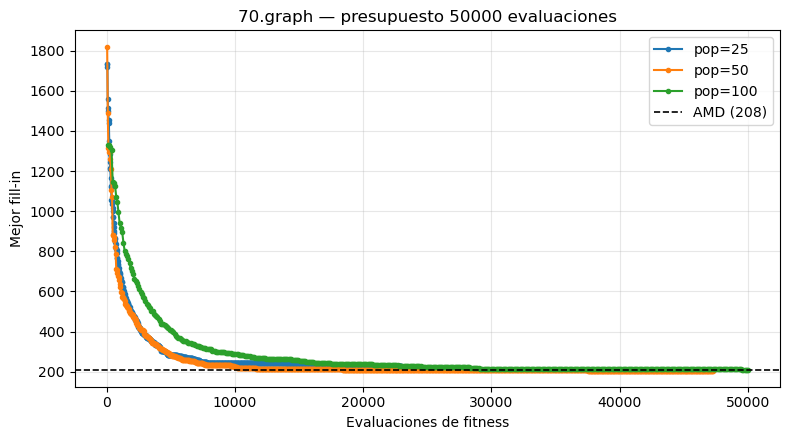

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, hist in histories.items():
    ax.plot(hist["evals"], hist["best_fillin"], marker=".", label=name)

ax.axhline(amd_fillin, color="black", linestyle="--", linewidth=1.2, label=f"AMD ({amd_fillin})")
ax.set_xlabel("Evaluaciones de fitness")
ax.set_ylabel("Mejor fill-in")
ax.set_title(f"{GRAPH_PATH.name} — presupuesto {MAX_EVALUATIONS} evaluaciones")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Cómo reutilizar esto con otro grafo

```python
G = load_pace_graph(ROOT / "data" / "raw" / "PACE2017B" / "otro.graph")
adj = nx_to_adj_matrix(G)
_, amd = greedy_minimum_degree(adj, compute_cost=True)

ea = GraphChordalizer(adj)
best, logbook = ea.run_ea(
    num_generations=10_000,
    population_size=50,
    max_evaluations=500,
    use_multiprocessing=False,
)
print(int(best.fitness.values[0]), int(logbook[-1]["evals"]), amd)
```

Para un experimento serio conviene varias semillas por configuración; aquí hay una sola corrida por población, suficiente para ilustrar el protocolo.